EDA & visualisations

Shape: (110526, 16)

Column names:
 ['patient_id', 'appointment_id', 'gender', 'scheduled_day', 'appointment_day', 'age', 'neighbourhood', 'scholarship', 'hypertension', 'diabetes', 'alcoholism', 'handicap', 'sms_received', 'no_show', 'wait_days', 'age_group']

Data types:
 patient_id         float64
appointment_id       int64
gender              object
scheduled_day       object
appointment_day     object
age                  int64
neighbourhood       object
scholarship          int64
hypertension         int64
diabetes             int64
alcoholism           int64
handicap             int64
sms_received         int64
no_show             object
wait_days            int64
age_group           object
dtype: object

Missing values:
 patient_id         0
appointment_id     0
gender             0
scheduled_day      0
appointment_day    0
age                0
neighbourhood      0
scholarship        0
hypertension       0
diabetes           0
alcoholism         0
handicap           0
sms_recei

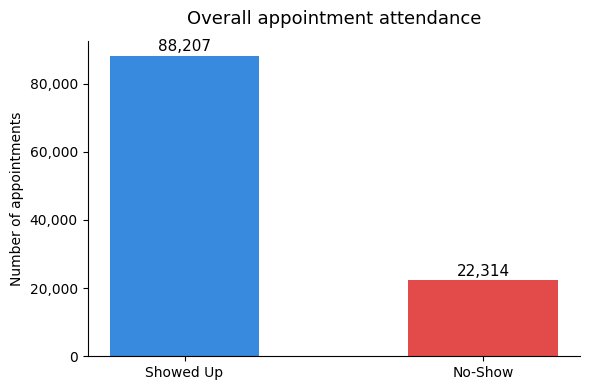

✅ Plot 1 saved


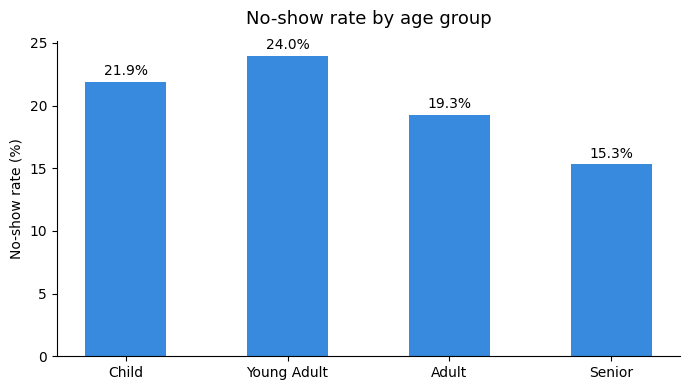

✅ Plot 2 saved


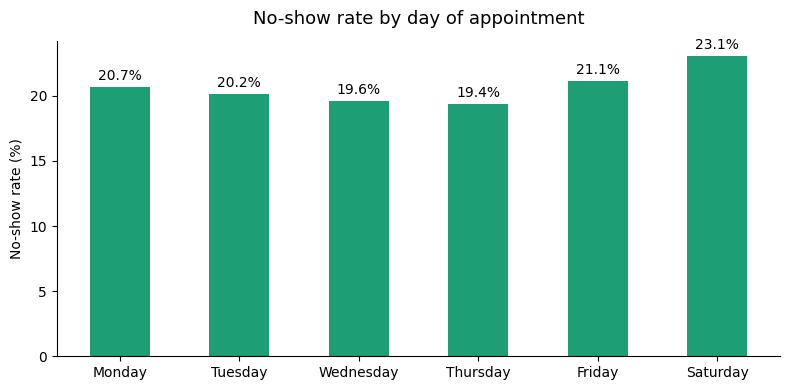

✅ Plot 3 saved


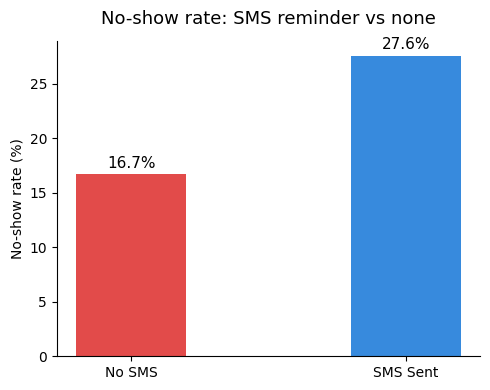

✅ Plot 4 saved


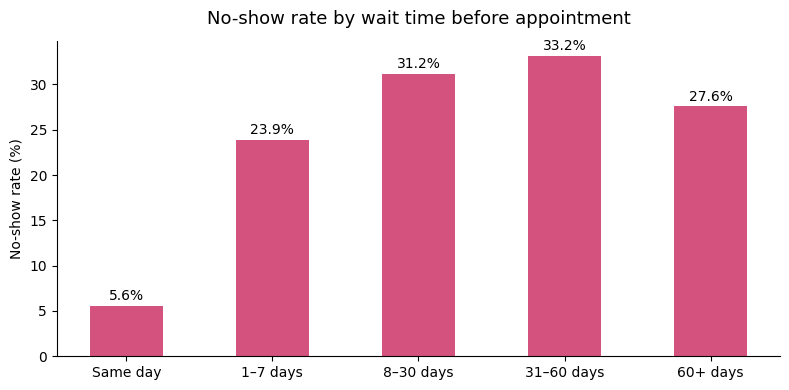

✅ Plot 5 saved

✅ hospital_final.csv exported for BigQuery
   Rows: 110521


In [4]:
# ============================================================
# Hospital Patient Behaviour Analysis - EDA
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

# ── 1. Load data ─────────────────────────────────────────────
df = pd.read_csv('hospital_clean.csv')

print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nFirst 5 rows:\n", df.head())

# ── 2. Clean & prep ──────────────────────────────────────────
# Convert date columns
df['scheduled_day'] = pd.to_datetime(df['scheduled_day'])
df['appointment_day'] = pd.to_datetime(df['appointment_day'])

# Make no_show a binary column (1 = did not show, 0 = showed up)
df['no_show_flag'] = df['no_show'].apply(lambda x: 1 if x == 'Yes' else 0)

# Recalculate wait_days cleanly in Python
df['wait_days'] = (df['appointment_day'] - df['scheduled_day']).dt.days

# Remove bad rows (negative wait days or negative age)
df = df[df['wait_days'] >= 0]
df = df[df['age'] >= 0]

# Add age group
def age_group(age):
    if age < 18:
        return 'Child'
    elif age < 35:
        return 'Young Adult'
    elif age < 60:
        return 'Adult'
    else:
        return 'Senior'

df['age_group'] = df['age'].apply(age_group)

# Add appointment day of week
df['day_of_week'] = df['appointment_day'].dt.day_name()

print("\n✅ Data cleaned. Rows remaining:", len(df))

# ── 3. Summary statistics ─────────────────────────────────────
total = len(df)
no_show_count = df['no_show_flag'].sum()
show_count = total - no_show_count
no_show_rate = round((no_show_count / total) * 100, 1)

print(f"\n📊 Total appointments : {total:,}")
print(f"   Showed up          : {show_count:,}")
print(f"   No-show            : {no_show_count:,}")
print(f"   No-show rate       : {no_show_rate}%")

# ── 4. Plot 1: Overall show vs no-show ───────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
labels = ['Showed Up', 'No-Show']
counts = [show_count, no_show_count]
colors = ['#378ADD', '#E24B4A']
bars = ax.bar(labels, counts, color=colors, width=0.5, edgecolor='none')

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 500,
            f'{count:,}', ha='center', va='bottom', fontsize=11)

ax.set_title('Overall appointment attendance', fontsize=13, pad=12)
ax.set_ylabel('Number of appointments')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('plot1_attendance.png', dpi=150)
plt.show()
print("✅ Plot 1 saved")

# ── 5. Plot 2: No-show rate by age group ─────────────────────
age_order = ['Child', 'Young Adult', 'Adult', 'Senior']
age_stats = df.groupby('age_group')['no_show_flag'].mean() * 100
age_stats = age_stats.reindex(age_order)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(age_stats.index, age_stats.values,
              color='#378ADD', width=0.5, edgecolor='none')

for bar, val in zip(bars, age_stats.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_title('No-show rate by age group', fontsize=13, pad=12)
ax.set_ylabel('No-show rate (%)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('plot2_age_group.png', dpi=150)
plt.show()
print("✅ Plot 2 saved")

# ── 6. Plot 3: No-show rate by day of week ───────────────────
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
day_stats = df.groupby('day_of_week')['no_show_flag'].mean() * 100
day_stats = day_stats.reindex(day_order).dropna()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(day_stats.index, day_stats.values,
              color='#1D9E75', width=0.5, edgecolor='none')

for bar, val in zip(bars, day_stats.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_title('No-show rate by day of appointment', fontsize=13, pad=12)
ax.set_ylabel('No-show rate (%)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('plot3_day_of_week.png', dpi=150)
plt.show()
print("✅ Plot 3 saved")

# ── 7. Plot 4: SMS reminder vs no-show rate ──────────────────
sms_stats = df.groupby('sms_received')['no_show_flag'].mean() * 100
sms_labels = ['No SMS', 'SMS Sent']

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(sms_labels, sms_stats.values,
              color=['#E24B4A', '#378ADD'], width=0.4, edgecolor='none')

for bar, val in zip(bars, sms_stats.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11)

ax.set_title('No-show rate: SMS reminder vs none', fontsize=13, pad=12)
ax.set_ylabel('No-show rate (%)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('plot4_sms.png', dpi=150)
plt.show()
print("✅ Plot 4 saved")

# ── 8. Plot 5: No-show rate by wait_days bucket ──────────────
df['wait_bucket'] = pd.cut(df['wait_days'],
                            bins=[-1, 0, 7, 30, 60, 180],
                            labels=['Same day', '1–7 days', '8–30 days',
                                    '31–60 days', '60+ days'])

wait_stats = df.groupby('wait_bucket', observed=True)['no_show_flag'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(wait_stats.index.astype(str), wait_stats.values,
              color='#D4537E', width=0.5, edgecolor='none')

for bar, val in zip(bars, wait_stats.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_title('No-show rate by wait time before appointment', fontsize=13, pad=12)
ax.set_ylabel('No-show rate (%)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('plot5_wait_days.png', dpi=150)
plt.show()
print("✅ Plot 5 saved")

# ── 9. Export final clean CSV for BigQuery ───────────────────
export_cols = ['patient_id', 'appointment_id', 'gender', 'scheduled_day',
               'appointment_day', 'age', 'age_group', 'neighbourhood',
               'scholarship', 'hypertension', 'diabetes', 'alcoholism',
               'handicap', 'sms_received', 'wait_days', 'day_of_week',
               'no_show', 'no_show_flag']

df[export_cols].to_csv('hospital_final.csv', index=False)
print("\n✅ hospital_final.csv exported for BigQuery")
print("   Rows:", len(df))